Using device: cpu | torch threads set to 24

SQUAT CLASSIFICATION - FIXED THRESHOLD (SI = 10) - FAST/CPU VERSION
Dataset path: C:\Users\admin\Downloads\A Multi-View Raw Video Dataset of Seven Fitness Ex\A Multi-View Raw Video Dataset of Seven Fitness Ex\Dataset Exercise Quality-wise\squat\New folder
SI Threshold: 10.0 (Fixed)
Rule: SI > 10.0 = Bad Squat
Input features: Position + Velocity + Acceleration + Jerk (12 channels)
Cache missing required keys. Re-extracting...

Found 150 videos. Processing...


100%|██████████| 150/150 [28:06<00:00, 11.25s/it]



✅ Total windows extracted: 6063
✅ Total videos processed: 150
   Using fixed threshold: SI > 10.0 = Bad
   Labels: 124 Good, 26 Bad

📊 Label distribution: {np.int64(0): np.int64(4991), np.int64(1): np.int64(1072)}

DATASET SUMMARY
Total windows: 6063
Classes found: 2
  Good: 4991 (82.3%)
  Bad: 1072 (17.7%)

💾 Cached extracted features to C:\Users\admin\Downloads\squat_features_cache_1 (1).pt

📊 Data split:
  Train: 4244 samples
  Validation: 909 samples
  Test: 910 samples

Training CTR-GCN...
Epoch 001 | Train Acc: 81.01% | Val Acc: 82.29% | Val F1: 0.7429
Epoch 002 | Train Acc: 82.19% | Val Acc: 83.72% | Val F1: 0.8456
Epoch 003 | Train Acc: 82.78% | Val Acc: 82.29% | Val F1: 0.7429
Epoch 004 | Train Acc: 82.42% | Val Acc: 82.29% | Val F1: 0.7429
Epoch 005 | Train Acc: 82.66% | Val Acc: 89.00% | Val F1: 0.8858
Epoch 006 | Train Acc: 82.68% | Val Acc: 82.29% | Val F1: 0.7429
Epoch 007 | Train Acc: 82.75% | Val Acc: 89.33% | Val F1: 0.8989
Epoch 008 | Train Acc: 84.33% | Val Acc: 91.

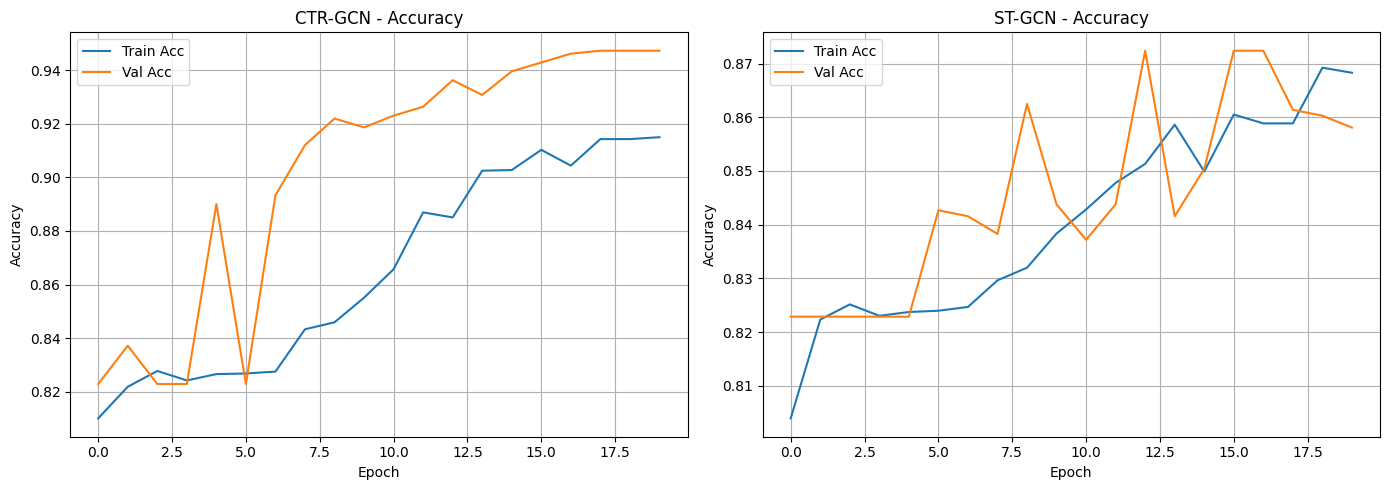

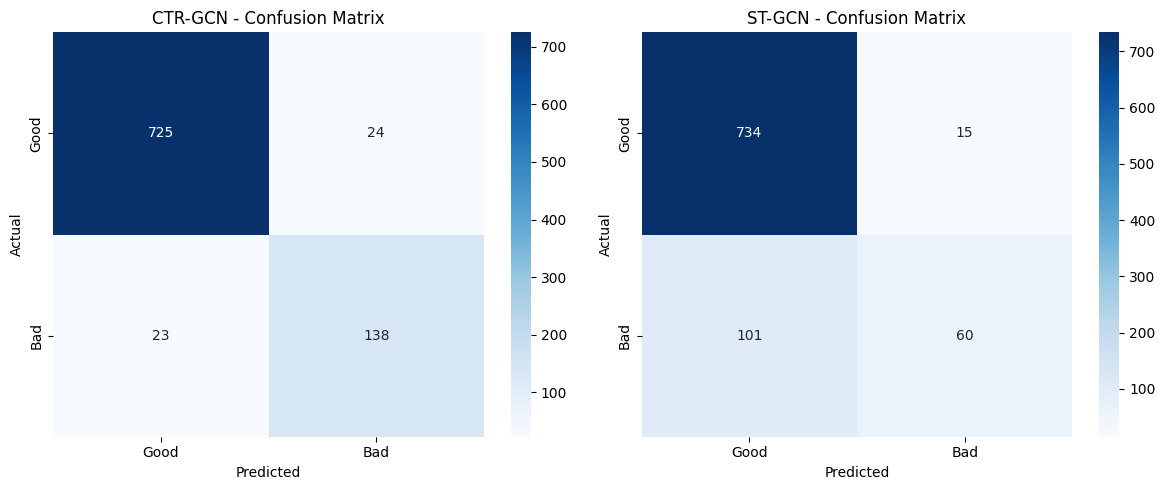


✅ All results saved to Downloads folder.

📁 Files saved:
   - Comparison_Accuracy.png
   - Comparison_Confusion.png

📊 Numeric results additionally saved to:
   - results_summary.csv      (test accuracy, F1, reports, confusion matrices)
   - training_history.csv     (loss/accuracy per epoch for each model)
   - classification_reports.txt (formatted classification reports)


In [6]:
import ssl
# --- Fix for Windows SSL/cert-store errors when MediaPipe tries to download a
# model file it doesn't have cached yet (SSLError: [ASN1: NOT_ENOUGH_DATA]).
# Tries certifi's certificate bundle first; falls back to an unverified
# context (only used for this local model download) if certifi is missing.
try:
    import certifi
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
except ImportError:
    ssl._create_default_https_context = ssl._create_unverified_context

import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================
VIDEO_DIR = r"C:\Users\admin\Downloads\A Multi-View Raw Video Dataset of Seven Fitness Ex\A Multi-View Raw Video Dataset of Seven Fitness Ex\Dataset Exercise Quality-wise\squat\New folder"          # <-- CHANGE THIS TO YOUR DATASET PATH

# ===== FIXED LABELLING STRATEGY =====
LABEL_STRATEGY = "threshold"  # Fixed: uses SI_THRESHOLD
SI_THRESHOLD = 10.0

# Other parameters
SEQ_LEN = 45                                    # frames per window
STRIDE = 10                                     # CHANGED: 5 -> 10 (fewer, still well-covered windows)
BATCH_SIZE = 32                                 # CHANGED: 16 -> 32 (fewer loop iters/epoch on CPU)
EPOCHS = 20                                      # CHANGED: 50 -> 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-3
SEED = 42
PATIENCE = 8                                     # CHANGED: 30 -> 8
EARLY_STOP_MIN_EPOCH = 10                        # CHANGED: 20 -> 10

# Which model(s) to train. Training only one roughly halves total time.
MODELS_TO_TRAIN = ["CTR-GCN", "ST-GCN"]          # e.g. change to ["ST-GCN"] to train just one

# Feature cache so re-runs skip MediaPipe extraction entirely
CACHE_FILE = os.path.join(os.path.expanduser("~"), "Downloads", "squat_features_cache_1 (1).pt")
FORCE_REEXTRACT = False                          # set True to ignore cache and re-extract from videos

# Graph adjacency for 17 joints
ADJ = [
    (0,1),(0,2),(1,3),(2,4), (5,6),(5,7),(7,9),(6,8),(8,10),
    (11,12),(11,13),(13,15),(12,14),(14,16), (5,11),(6,12)
]

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CPU is the target here, so make sure PyTorch actually uses all cores.
if device.type == 'cpu':
    n_threads = os.cpu_count() or 4
    torch.set_num_threads(n_threads)
    print(f"Using device: {device} | torch threads set to {n_threads}")
else:
    print(f"Using device: {device}")

def get_adj_matrix():
    A = np.eye(17)
    for i, j in ADJ:
        A[i, j] = A[j, i] = 1
    D = np.diag(np.sum(A, axis=1)**-0.5)
    A_norm = D @ A @ D
    return torch.FloatTensor(A_norm)

# =============================================================================
# SKELETON UTILS & PROCESSOR
# =============================================================================
class SkeletonUtils:
    @staticmethod
    def normalize(coords):
        mid_hip = (coords[:, 11, :] + coords[:, 12, :]) / 2
        coords = coords - mid_hip[:, np.newaxis, :]
        shoulder_mid = (coords[:, 0, :] + coords[:, 1, :]) / 2
        hip_mid = (coords[:, 11, :] + coords[:, 12, :]) / 2
        body_scale = np.linalg.norm(shoulder_mid - hip_mid, axis=-1).mean()
        if body_scale > 1e-6:
            coords = coords / body_scale
        mean = coords.mean(axis=0, keepdims=True)
        std = coords.std(axis=0, keepdims=True) + 1e-8
        coords = (coords - mean) / std
        return coords

    @staticmethod
    def calculate_angle(a, b, c):
        a, b, c = np.array(a), np.array(b), np.array(c)
        ba = a - b
        bc = c - b
        cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
        return np.degrees(angle)

    @staticmethod
    def augment_batch(x):
        """
        Vectorized augmentation applied to a whole batch at once.
        x: (B, C, T, V) with C=12 (pos + vel + acc + jerk)
        """
        x = x.clone()
        B = x.size(0)
        # Split channels into four 3‑D components
        pos = x[:, 0:3]   # (B, 3, T, V)
        vel = x[:, 3:6]
        acc = x[:, 6:9]
        jerk = x[:, 9:12]

        # Noise (all samples at once)
        x += torch.randn_like(x) * 0.02

        # Random rotation around Y (applied per‑sample but batched)
        do_rot = torch.rand(B) > 0.5
        if do_rot.any():
            angles = (torch.rand(B) - 0.5) * 0.3
            c, s = torch.cos(angles), torch.sin(angles)
            zeros, ones = torch.zeros(B), torch.ones(B)
            rot = torch.stack([
                torch.stack([c, zeros, s], dim=1),
                torch.stack([zeros, ones, zeros], dim=1),
                torch.stack([-s, zeros, c], dim=1),
            ], dim=1).to(x.device)   # (B, 3, 3)

            idx = do_rot.nonzero(as_tuple=True)[0]
            # Extract and rotate each 3‑D component for the selected samples
            pos_sub = pos[idx]  # (b, 3, T, V)
            vel_sub = vel[idx]
            acc_sub = acc[idx]
            jerk_sub = jerk[idx]
            b, _, T, V = pos_sub.shape
            # Flatten spatial-temporal dimensions to (b, 3, T*V)
            pos_flat = pos_sub.view(b, 3, -1)  # (b, 3, T*V)
            vel_flat = vel_sub.view(b, 3, -1)
            acc_flat = acc_sub.view(b, 3, -1)
            jerk_flat = jerk_sub.view(b, 3, -1)

            rot_sub = rot[idx]  # (b, 3, 3)
            # Apply rotation: new = rot_sub @ old (matrix multiplication over last dims)
            pos_rot = torch.matmul(rot_sub, pos_flat)  # (b, 3, T*V)
            vel_rot = torch.matmul(rot_sub, vel_flat)
            acc_rot = torch.matmul(rot_sub, acc_flat)
            jerk_rot = torch.matmul(rot_sub, jerk_flat)

            # Reshape back to (b, 3, T, V)
            pos[idx] = pos_rot.view(b, 3, T, V)
            vel[idx] = vel_rot.view(b, 3, T, V)
            acc[idx] = acc_rot.view(b, 3, T, V)
            jerk[idx] = jerk_rot.view(b, 3, T, V)

        # Reconstruct x
        x = torch.cat([pos, vel, acc, jerk], dim=1)  # (B, 12, T, V)

        # Random per-sample scaling (applied to all channels)
        scale = 1 + (torch.rand(B, 1, 1, 1) - 0.5) * 0.2
        x = x * scale
        return x

class SquatProcessor:
    def __init__(self):
        self.pose = mp.solutions.pose.Pose(
            static_image_mode=False,
            model_complexity=1,          # REVERTED to 1: this model is already cached locally
                                          # from your earlier runs, so it avoids triggering a new
                                          # download (which was hitting the Windows SSL cert bug).
                                          # If you want to try complexity=0 for extra speed once
                                          # the SSL fix above is confirmed working, change this to 0.
            min_detection_confidence=0.5
        )

    def get_si(self, left_angle, right_angle):
        return ((left_angle - right_angle) / (0.5 * (left_angle + right_angle) + 1e-6)) * 100

    def process_video(self, path):
        cap = cv2.VideoCapture(path)
        coords = []
        frame_data = []

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.pose.process(img)

            if res.pose_world_landmarks:
                wlm = res.pose_world_landmarks.landmark
                pts = [[lm.x, lm.y, lm.z] for lm in wlm[12:29]]
                coords.append(pts)

                left_knee = SkeletonUtils.calculate_angle(
                    [wlm[23].x, wlm[23].y, wlm[23].z],
                    [wlm[25].x, wlm[25].y, wlm[25].z],
                    [wlm[27].x, wlm[27].y, wlm[27].z]
                )
                right_knee = SkeletonUtils.calculate_angle(
                    [wlm[24].x, wlm[24].y, wlm[24].z],
                    [wlm[26].x, wlm[26].y, wlm[26].z],
                    [wlm[28].x, wlm[28].y, wlm[28].z]
                )
                si = self.get_si(left_knee, right_knee)

                frame_data.append({
                    'si': si,
                    'left_knee': left_knee,
                    'right_knee': right_knee,
                    'avg_knee': (left_knee + right_knee) / 2,
                    'label': 1 if si > SI_THRESHOLD else 0
                })

        cap.release()
        if len(coords) < SEQ_LEN:
            return None, None, None

        coords = SkeletonUtils.normalize(np.array(coords))

        avg_si = np.mean([d['si'] for d in frame_data])
        avg_left_knee = np.mean([d['left_knee'] for d in frame_data])
        avg_right_knee = np.mean([d['right_knee'] for d in frame_data])
        avg_knee = (avg_left_knee + avg_right_knee) / 2

        frame_labels = [d['label'] for d in frame_data]
        final_label = 1 if np.mean(frame_labels) > 0.4 else 0

        return coords, frame_data, {
            'avg_si': avg_si,
            'avg_left_knee': avg_left_knee,
            'avg_right_knee': avg_right_knee,
            'avg_knee': avg_knee,
            'video_name': os.path.basename(path),
            'final_label': final_label
        }

# =============================================================================
# LABELLING STRATEGY (Fixed threshold)
# =============================================================================
def label_videos(all_video_metrics):
    video_labels = {}
    print(f"   Using fixed threshold: SI > {SI_THRESHOLD} = Bad")

    for m in all_video_metrics:
        video_labels[m['video_name']] = m['final_label']

    num_bad = sum(1 for v in video_labels.values() if v == 1)
    num_good = len(video_labels) - num_bad
    print(f"   Labels: {num_good} Good, {num_bad} Bad")

    return video_labels

# =============================================================================
# DATA EXTRACTION (single pass now — this is the main speed fix)
# =============================================================================
def extract_all_data():
    # Use cached features if available, so re-runs skip MediaPipe entirely.
    use_cache = not FORCE_REEXTRACT and os.path.exists(CACHE_FILE)
    if use_cache:
        try:
            cache = torch.load(CACHE_FILE)
            # Check that all required keys exist
            if not all(k in cache for k in ['X', 'y', 'num_classes']):
                print("Cache missing required keys. Re-extracting...")
                use_cache = False
            else:
                X, y, num_classes = cache['X'], cache['y'], cache['num_classes']
                # Check channel dimension: must be 12
                if X.size(1) != 12:
                    print(f"Cache has {X.size(1)} channels, but expected 12. Re-extracting...")
                    use_cache = False
                else:
                    print(f"\n✅ Loading cached features from {CACHE_FILE}")
                    print(f"   Loaded {len(X)} windows, {num_classes} classes.")
                    return X, y, num_classes
        except Exception as e:
            print(f"Error loading cache: {e}. Re-extracting...")
            use_cache = False

    # If we are here, we need to extract from videos
    proc = SquatProcessor()
    X = []
    window_video_names = []
    all_video_metrics = []

    videos = glob.glob(os.path.join(VIDEO_DIR, "*.mp4")) + \
             glob.glob(os.path.join(VIDEO_DIR, "*.avi")) + \
             glob.glob(os.path.join(VIDEO_DIR, "*.mov"))

    if not videos:
        raise ValueError(f"No video files found in {VIDEO_DIR}")

    print(f"\nFound {len(videos)} videos. Processing...")

    # SINGLE PASS: extract windows, metrics, and window->video mapping together.
    for v in tqdm(videos):
        coords, frame_data, metrics = proc.process_video(v)
        if coords is not None:
            all_video_metrics.append(metrics)
            video_name = metrics['video_name']

            for i in range(0, len(coords) - SEQ_LEN, STRIDE):
                window = coords[i:i+SEQ_LEN]  # (T, V, 3)
                # Compute derivatives
                vel = np.diff(window, axis=0, append=window[-1:])           # (T, V, 3)
                acc = np.diff(vel, axis=0, append=vel[-1:])                 # (T, V, 3)
                jerk = np.diff(acc, axis=0, append=acc[-1:])                # (T, V, 3)
                # Concatenate along feature dimension -> (T, V, 12)
                combined = np.concatenate([window, vel, acc, jerk], axis=-1)
                combined = combined.transpose(2, 0, 1)  # (12, T, V)
                X.append(combined)
                window_video_names.append(video_name)

    if not X:
        raise ValueError("No valid data extracted. Check videos.")

    print(f"\n✅ Total windows extracted: {len(X)}")
    print(f"✅ Total videos processed: {len(all_video_metrics)}")

    video_labels = label_videos(all_video_metrics)
    y = [video_labels[name] for name in window_video_names]

    unique_labels = np.unique(y)
    print(f"\n📊 Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

    X = torch.FloatTensor(np.array(X))
    y = torch.LongTensor(np.array(y))

    print("\n" + "="*60)
    print("DATASET SUMMARY")
    print("="*60)
    print(f"Total windows: {len(X)}")
    print(f"Classes found: {len(unique_labels)}")
    for label in sorted(unique_labels):
        class_name = "Good" if label == 0 else "Bad"
        count = (y == label).sum().item()
        print(f"  {class_name}: {count} ({count/len(y)*100:.1f}%)")

    if len(unique_labels) < 2:
        print("\n" + "="*60)
        print("⚠️  WARNING: ONLY ONE CLASS FOUND!")
        print("="*60)
        print(f"All videos have SI <= {SI_THRESHOLD} (Good squats)")
        print("This means the dataset has no 'Bad' squats at this threshold.")
        print("\nOptions:")
        print("1. Keep as-is: Train a model to recognize 'Good' vs 'Not Good' (anomaly detection)")
        print("2. Lower the threshold (change SI_THRESHOLD to e.g., 5)")
        print("3. Use a different labelling strategy")
        print("="*60)

    # Cache to disk for instant reload next time.
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)
    torch.save({'X': X, 'y': y, 'num_classes': len(unique_labels)}, CACHE_FILE)
    print(f"\n💾 Cached extracted features to {CACHE_FILE}")

    return X, y, len(unique_labels)

# =============================================================================
# MODELS (CHANNEL WIDTH REDUCED BY HALF, NOW INPUT CHANNELS = 12)
# =============================================================================
class CTR_GC(nn.Module):
    def __init__(self, in_c, out_c, adj):
        super().__init__()
        self.adj = nn.Parameter(adj, requires_grad=False)
        self.refine = nn.Conv2d(in_c, out_c, 1)
        self.pa = nn.Parameter(torch.randn(out_c, 17, 17) * 0.01)
        self.alpha = nn.Parameter(torch.ones(1))

    def forward(self, x):
        x = self.refine(x)
        A = self.alpha * self.adj.unsqueeze(0) + self.pa
        x = torch.einsum('bctv,cvw->bctw', x, A)
        return x

class CTRGCN_Block(nn.Module):
    def __init__(self, in_c, out_c, adj, stride=1, dropout=0.6):
        super().__init__()
        self.gcn = CTR_GC(in_c, out_c, adj)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, (9, 1), (stride, 1), (4, 0)),
            nn.BatchNorm2d(out_c), nn.Dropout(dropout)
        )
        self.res = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.tcn(self.gcn(x)) + self.res(x))

class CTRGCN(nn.Module):
    def __init__(self, in_channels=12, num_classes=2):   # <-- changed default to 12
        super().__init__()
        adj = get_adj_matrix()
        self.block1 = CTRGCN_Block(in_channels, 8, adj, dropout=0.6)
        self.block2 = CTRGCN_Block(8, 16, adj, dropout=0.6)
        self.block3 = CTRGCN_Block(16, 32, adj, dropout=0.7)
        self.block4 = CTRGCN_Block(32, 64, adj, dropout=0.7)
        self.block5 = CTRGCN_Block(64, 128, adj, dropout=0.8)
        self.block6 = CTRGCN_Block(128, 256, adj, dropout=0.8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.8),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

class ST_GCN_Layer(nn.Module):
    def __init__(self, in_c, out_c, adj, stride=1, dropout=0.6):
        super().__init__()
        self.adj = nn.Parameter(adj, requires_grad=False)
        self.gcn = nn.Conv2d(in_c, out_c, kernel_size=1)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, (9, 1), (stride, 1), (4, 0)),
            nn.BatchNorm2d(out_c), nn.Dropout(dropout)
        )
        self.residual = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        res = self.residual(x)
        x = torch.einsum('nctv,vw->nctw', x, self.adj)
        x = self.gcn(x)
        x = self.tcn(x) + 0.6 * res
        return self.relu(x)

class STGCN(nn.Module):
    def __init__(self, in_channels=12, num_classes=2):   # <-- changed default to 12
        super().__init__()
        adj = get_adj_matrix()
        self.layer1 = ST_GCN_Layer(in_channels, 8, adj, dropout=0.6)
        self.layer2 = ST_GCN_Layer(8, 16, adj, dropout=0.6)
        self.layer3 = ST_GCN_Layer(16, 32, adj, dropout=0.7)
        self.layer4 = ST_GCN_Layer(32, 64, adj, dropout=0.7)
        self.layer5 = ST_GCN_Layer(64, 128, adj, dropout=0.8)
        self.layer6 = ST_GCN_Layer(128, 256, adj, dropout=0.8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.8),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

# =============================================================================
# FOCAL LOSS (handles imbalance)
# =============================================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# =============================================================================
# EVALUATION
# =============================================================================
def evaluate(model, loader, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            if criterion:
                loss = criterion(output, target)
                total_loss += loss.item()
            all_preds.extend(torch.argmax(output, 1).cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1, total_loss/len(loader) if criterion else 0, all_labels, all_preds

# =============================================================================
# TRAINING FUNCTION
# =============================================================================
def train_model(model_name, train_loader, val_loader, test_loader, num_classes=2):
    if model_name == "CTR-GCN":
        model = CTRGCN(in_channels=12, num_classes=num_classes).to(device)   # <-- pass 12
    else:
        model = STGCN(in_channels=12, num_classes=num_classes).to(device)    # <-- pass 12
    print(f"\n{'='*50}\nTraining {model_name}...\n{'='*50}")

    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_val_f1 = -1.0
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        correct_train = 0
        total_train = 0

        for data, target in train_loader:
            # Vectorized batch augmentation (now handles 12 channels)
            data = SkeletonUtils.augment_batch(data)
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            _, pred = torch.max(output, 1)
            correct_train += (pred == target).sum().item()
            total_train += target.size(0)

        train_acc = correct_train / total_train
        val_acc, val_f1, val_loss, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(epoch_loss/len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"Epoch {epoch+1:03d} | Train Acc: {train_acc:.2%} | Val Acc: {val_acc:.2%} | Val F1: {val_f1:.4f}")

        if patience_counter >= PATIENCE and epoch > EARLY_STOP_MIN_EPOCH:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    test_acc, test_f1, _, y_true, y_pred = evaluate(model, test_loader)
    print(f"\n{model_name} Test Accuracy: {test_acc:.4f} ({test_acc:.2%})")
    print(f"{model_name} Test Weighted F1: {test_f1:.4f}")
    print("\nClassification Report:")
    target_names = ['Good', 'Bad'][:num_classes]
    print(classification_report(y_true, y_pred, target_names=target_names))

    return test_acc, test_f1, history, y_true, y_pred

# =============================================================================
# MAIN
# =============================================================================
def main():
    print("\n" + "="*70)
    print("SQUAT CLASSIFICATION - FIXED THRESHOLD (SI = 10) - FAST/CPU VERSION")
    print("="*70)
    print(f"Dataset path: {VIDEO_DIR}")
    print(f"SI Threshold: {SI_THRESHOLD} (Fixed)")
    print(f"Rule: SI > {SI_THRESHOLD} = Bad Squat")
    print(f"Input features: Position + Velocity + Acceleration + Jerk (12 channels)")  # <-- new

    X, y, num_classes = extract_all_data()

    unique_labels = torch.unique(y)
    if len(unique_labels) < 2:
        print(f"\n⚠️  WARNING: Only {len(unique_labels)} class present!")
        print(f"   All squats are labelled as 'Good' at SI > {SI_THRESHOLD}")
        print(f"   This means your dataset has no 'Bad' squats.")
        print(f"   Training will still run, but it will be a single-class scenario.")
        print(f"   Consider using a different dataset if you want binary classification.")

    min_class_count = min([(y == label).sum().item() for label in unique_labels]) if len(unique_labels) > 0 else 0

    if min_class_count < 2:
        print(f"\n⚠️  WARNING: One class has only {min_class_count} sample(s).")
        print("   Using simple split instead of stratified split.")

        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, random_state=SEED
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=SEED
        )
    else:
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, random_state=SEED, stratify=y
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
        )

    print(f"\n📊 Data split:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Validation: {len(X_val)} samples")
    print(f"  Test: {len(X_test)} samples")

    train_loader = DataLoader(
        list(zip(X_train, y_train)), BATCH_SIZE, shuffle=True, pin_memory=(device.type=='cuda')
    )
    val_loader = DataLoader(
        list(zip(X_val, y_val)), BATCH_SIZE, pin_memory=(device.type=='cuda')
    )
    test_loader = DataLoader(
        list(zip(X_test, y_test)), BATCH_SIZE, pin_memory=(device.type=='cuda')
    )

    results = {}
    for model_name in MODELS_TO_TRAIN:
        acc, f1, hist, y_true, y_pred = train_model(
            model_name, train_loader, val_loader, test_loader, num_classes
        )
        results[model_name] = {'accuracy': acc, 'f1': f1, 'history': hist, 'y_true': y_true, 'y_pred': y_pred}

    print("\n" + "="*60)
    print("FINAL COMPARISON")
    print("="*60)
    for name, res in results.items():
        print(f"{name:10s} | Test Acc: {res['accuracy']:.4f} ({res['accuracy']:.2%}) | F1: {res['f1']:.4f}")

    fig, axes = plt.subplots(1, len(results), figsize=(7*len(results), 5), squeeze=False)
    for i, (name, res) in enumerate(results.items()):
        ax = axes[0][i]
        ax.plot(res['history']['train_acc'], label='Train Acc')
        ax.plot(res['history']['val_acc'], label='Val Acc')
        ax.set_title(f'{name} - Accuracy')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(os.path.expanduser("~"), "Downloads", "Comparison_Accuracy.png"), dpi=300)
    plt.show()

    fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5), squeeze=False)
    target_names = ['Good', 'Bad'][:num_classes]
    for i, (name, res) in enumerate(results.items()):
        cm = confusion_matrix(res['y_true'], res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names,
                    ax=axes[0][i])
        axes[0][i].set_title(f'{name} - Confusion Matrix')
        axes[0][i].set_ylabel('Actual')
        axes[0][i].set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(os.path.expanduser("~"), "Downloads", "Comparison_Confusion.png"), dpi=300)
    plt.show()

    print("\n✅ All results saved to Downloads folder.")
    print("\n📁 Files saved:")
    print("   - Comparison_Accuracy.png")
    print("   - Comparison_Confusion.png")
        # --- ADDED: Save numeric results to CSV and text files ---
    # Summary of test metrics (accuracy, F1, report, confusion matrix)
    results_summary = []
    for name, res in results.items():
        # Classification report as a string
        report_str = classification_report(
            res['y_true'], res['y_pred'],
            target_names=target_names,
            output_dict=False
        )
        # Confusion matrix as a string
        cm = confusion_matrix(res['y_true'], res['y_pred'])
        cm_str = np.array2string(cm, separator=', ')
        results_summary.append({
            'Model': name,
            'Test Accuracy': res['accuracy'],
            'Test F1': res['f1'],
            'Classification Report': report_str,
            'Confusion Matrix': cm_str
        })
    results_df = pd.DataFrame(results_summary)
    results_df.to_csv(
        os.path.join(os.path.expanduser("~"), "Downloads", "results_summary.csv"),
        index=False
    )

    # Per‑epoch training history
    history_data = []
    for name, res in results.items():
        for epoch in range(len(res['history']['train_acc'])):
            history_data.append({
                'Model': name,
                'Epoch': epoch + 1,
                'Train Loss': res['history']['train_loss'][epoch],
                'Train Acc': res['history']['train_acc'][epoch],
                'Val Loss': res['history']['val_loss'][epoch],
                'Val Acc': res['history']['val_acc'][epoch],
                'Val F1': res['history']['val_f1'][epoch]
            })
    history_df = pd.DataFrame(history_data)
    history_df.to_csv(
        os.path.join(os.path.expanduser("~"), "Downloads", "training_history.csv"),
        index=False
    )

    # Classification reports as a single text file (more readable)
    report_text = ""
    for name, res in results.items():
        report_text += f"Model: {name}\n"
        report_text += classification_report(
            res['y_true'], res['y_pred'],
            target_names=target_names,
            output_dict=False
        )
        report_text += "\n\n"
    with open(
        os.path.join(os.path.expanduser("~"), "Downloads", "classification_reports.txt"),
        "w"
    ) as f:
        f.write(report_text)

    print("\n📊 Numeric results additionally saved to:")
    print("   - results_summary.csv      (test accuracy, F1, reports, confusion matrices)")
    print("   - training_history.csv     (loss/accuracy per epoch for each model)")
    print("   - classification_reports.txt (formatted classification reports)")
    # --- End of added code ---

if __name__ == "__main__":
    main()